Multi Agent RAG

- multi agent network

api keys and LLM setup

In [72]:
import os
from dotenv import load_dotenv
load_dotenv()
from langchain.chat_models import init_chat_model
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

llm = init_chat_model("groq:llama-3.1-8b-instant")
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.11'}}, output_version=None, profile={'name': 'Llama 3.1 8B Instant', 'release_date': '2024-07-23', 'last_updated': '2024-07-23', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 131072, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000002A58C040770>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000002A58C04E9C0>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

Building the individual agents
- researcher agent
- blog writer agent

In [73]:
#libraries
from typing import Annotated,Literal
from langchain_tavily import TavilySearch
from langchain_core.tools import tool,Tool
from langchain_community.utilities.wikidata import WikidataAPIWrapper
from langchain_community.tools.wikipedia.tool import WikipediaQueryRun
from langchain_community.document_loaders import TextLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_huggingface import HuggingFaceEmbeddings

building the tools

In [74]:
tavily_tool = TavilySearch(max_results=5)
tavily_tool

TavilySearch(max_results=5, api_wrapper=TavilySearchAPIWrapper(tavily_api_key=SecretStr('**********'), api_base_url=None))

In [75]:
def make_retriever_tool_from_text(file,name,desc):
    docs = TextLoader(file,encoding="utf-8").load()
    chunks = RecursiveCharacterTextSplitter(chunk_size=500,chunk_overlap=50).split_documents(docs)
    vs = FAISS.from_documents(chunks,HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2"))
    retriever = vs.as_retriever()
    
    def tool_func(query: str) -> str:
        result = retriever.invoke(query)
        return "\n\n".join(doc.page_content for doc in result)
    
    return Tool(name=name,description=desc,func=tool_func)

internal_tool_1 = make_retriever_tool_from_text("research_notes.txt","ResearchNotesTool","Search research notes for projects and other information")
internal_tool_1

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Tool(name='ResearchNotesTool', description='Search research notes for projects and other information', func=<function make_retriever_tool_from_text.<locals>.tool_func at 0x000002A58CFA23E0>)

In [76]:
from langchain_core.messages import BaseMessage, HumanMessage
from langgraph.graph import MessagesState,END
from langchain.agents import create_agent
from langgraph.types import Command

def get_nextnode(last_message: BaseMessage,goto: str):
    content = last_message.content
    if isinstance(content,str) and 'FINAL ANSWER' in last_message.content:
        return END
    return goto

In [77]:
def make_system_prompt(suffix: str) -> str:
    return (
        f"""You are a helpful AI assistant, collaborating with other assitants.
        Use the provided tools to progress towards answering the question
        If you are unable to fully answer, thats OK, another assitant with different tools
        will help where you left off. Execute what you can to make progress.
        If you or any of the other assitants have the final answer or deliverbale,
        prefix your response with FINAL ANSWER so the team knows to stop.
        \n{suffix}"""
    )

Building the Research Agent and Node

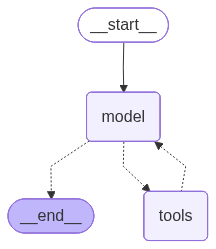

In [78]:
research_agent = create_agent(
    llm,
    tools=[internal_tool_1,tavily_tool],
)
research_agent

In [79]:
def research_node(state: MessagesState) -> Command[Literal["blog_generator",END]]:
    result = research_agent.invoke({
        "messages":[
            {
                "role":"system",
                "content":make_system_prompt("You can only do research. You are working with a content writer colleague."),
            },
            *state['messages'],
        ]
    })
    goto = get_nextnode(result["messages"][-1],"blog_generator")
    # not all providers allow ai msg since wrapping it in human message
    result["messages"][-1] = HumanMessage(
        content=result["messages"][-1].content,
        name="researcher"
    )
    return Command(
        update={
            "messages":result["messages"]
        },
        goto=goto
    )

Building the Blog Writer Agent and Node

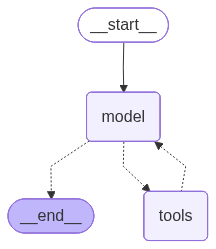

In [80]:
blog_agent = create_agent(
    llm,
    tools=[tavily_tool]
)
blog_agent

In [81]:
def blog_node(state: MessagesState) -> Command[Literal["researcher",END]]:
    result = blog_agent.invoke({
        "messages":[
            {
                "role":"system",
                "content":make_system_prompt("You can only write a detailed blog. You are working with a researcher colleague."),
            },
            *state['messages']
        ]
    })
    goto = get_nextnode(result["messages"][-1],"researcher")
    result["messages"][-1] = HumanMessage(
        content=result["messages"][-1].content,
        name="blog_generator"
    )
    return Command(
        update={
            "messages":result["messages"]
        },
        goto=goto
    )

building the graph

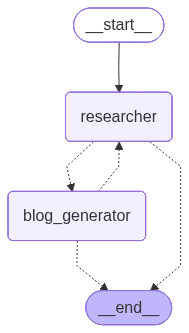

In [82]:
from langgraph.graph import StateGraph,START
workflow = StateGraph(MessagesState)
workflow.add_node("researcher",research_node)
workflow.add_node("blog_generator",blog_node)
workflow.add_edge(START,"researcher")
graph = workflow.compile()
graph

testing the system

In [83]:
response = graph.invoke(
    {
        "messages": [
            {"role": "user", "content": "Write a detailed blog on project Falcon, Nova and Atlas"}
        ]
    },
    config={"recursion_limit": 25}
)
response

APIStatusError: Error code: 413 - {'error': {'message': 'Request too large for model `llama-3.1-8b-instant` in organization `org_01kvj5s29efhr9w67feczgxz75` service tier `on_demand` on tokens per minute (TPM): Limit 6000, Requested 8014, please reduce your message size and try again. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}}